# Business Problem

Modern manufacturing industries rely heavily on the continuous operation of industrial machines. Unexpected machine failures can lead to unplanned downtime, increased maintenance costs, production delays, and reduced operational efficiency.

Traditional maintenance strategies, such as reactive maintenance (repairing equipment after failure) and preventive maintenance (scheduled servicing), often result in unnecessary maintenance activities or unexpected equipment breakdowns.

Predictive Maintenance addresses this challenge by leveraging machine learning techniques to predict equipment failures before they occur. By analyzing historical operational data and machine sensor measurements, predictive models can identify early signs of failure, enabling maintenance teams to perform timely interventions.

The primary objective of this project is to develop a multiclass machine learning model capable of predicting different types of machine failures based on operational parameters. Early identification of failure modes allows industries to reduce downtime, improve equipment reliability, optimize maintenance schedules, and lower operational costs.

This project follows a complete end-to-end machine learning workflow, including data preprocessing, feature engineering, handling class imbalance, model development, evaluation, model selection, and deployment preparation.

# Dataset Description

This project uses the **AI4I 2020 Predictive Maintenance Dataset**, a synthetic dataset designed to simulate real-world industrial machine operations and failure scenarios.

The dataset contains operational measurements collected from industrial machines under different working conditions. Each record represents the condition of a machine at a particular point in time and includes both process variables and failure information.

## Features

| Feature | Description |
|---------|-------------|
| Type | Machine quality type (L, M, H) |
| Air Temperature [K] | Ambient air temperature surrounding the machine |
| Process Temperature [K] | Internal process temperature during machine operation |
| Rotational Speed [rpm] | Rotation speed of the machine tool |
| Torque [Nm] | Applied torque during operation |
| Tool Wear [min] | Accumulated tool wear time |

## Target Variable

The target variable represents the machine failure category.

| Label | Failure Type |
|-------|--------------|
| 0 | No Failure |
| 1 | Tool Wear Failure (TWF) |
| 2 | Heat Dissipation Failure (HDF) |
| 3 | Power Failure (PWF) |
| 4 | Overstrain Failure (OSF) |
| 5 | Other Failure |

The dataset is **highly imbalanced**, with the majority of observations belonging to the **No Failure** class and only a small number representing different failure types. This imbalance makes overall accuracy an insufficient evaluation metric and motivates the use of metrics such as **Macro F1 Score**, **Precision**, **Recall**, and **Confusion Matrix** for comprehensive model evaluation.

# Project Objective

The primary objective of this project is to build a robust machine learning model capable of accurately predicting machine failure types from operational sensor data.

The project aims to:

- Perform comprehensive exploratory data analysis (EDA).
- Engineer meaningful features from raw sensor measurements.
- Handle class imbalance using oversampling techniques.
- Build and compare multiple machine learning models.
- Evaluate models using metrics suitable for imbalanced multiclass classification.
- Select the most appropriate model based on both statistical performance and practical predictive maintenance requirements.
- Prepare the trained model for deployment using a production-ready prediction pipeline.

# Why Predictive Maintenance Matters

Machine failures can significantly impact manufacturing operations by causing unexpected downtime, production losses, increased maintenance expenses, and safety risks.

An effective predictive maintenance system provides several benefits:

- Reduces unplanned equipment downtime.
- Minimizes maintenance costs.
- Improves production efficiency.
- Extends equipment lifespan.
- Enables data-driven maintenance scheduling.
- Improves overall operational reliability.

By predicting failures before they occur, organizations can transition from reactive maintenance strategies to proactive, condition-based maintenance.

# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.base import BaseEstimator, ClassifierMixin

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, SVMSMOTE

# Load Dataset

In [2]:
df = pd.read_csv('ai4i2020.csv')

In [3]:
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


# EDA

In [4]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [6]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.skew(numeric_only = True)

UDI                         0.000000
Air temperature [K]         0.114274
Process temperature [K]     0.015027
Rotational speed [rpm]      1.993171
Torque [Nm]                -0.009517
Tool wear [min]             0.027292
Machine failure             5.151852
TWF                        14.644462
HDF                         9.164789
PWF                        10.114516
OSF                         9.953916
RNF                        22.879570
dtype: float64

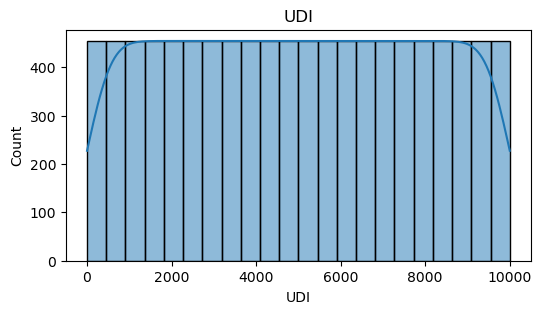

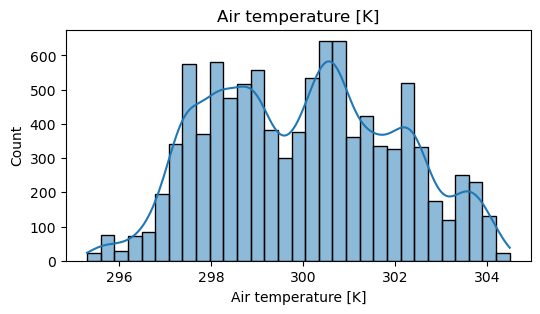

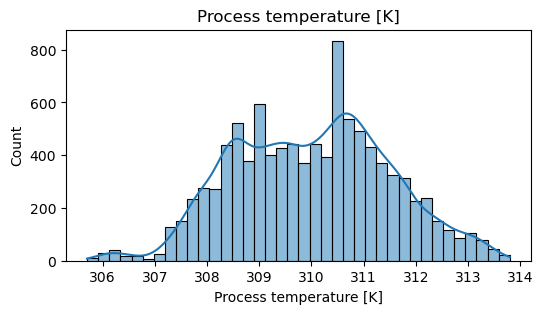

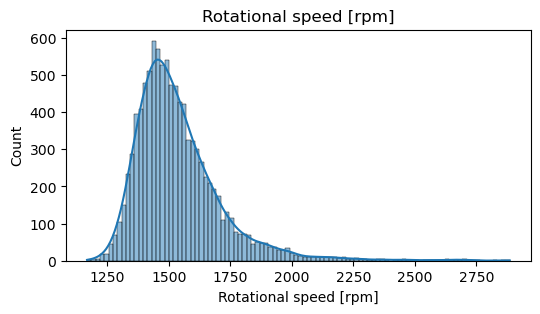

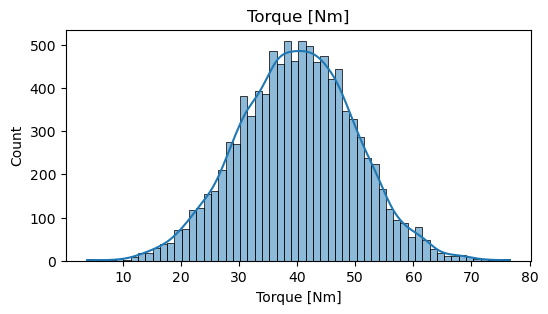

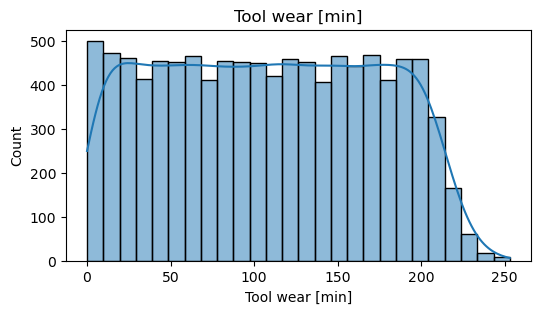

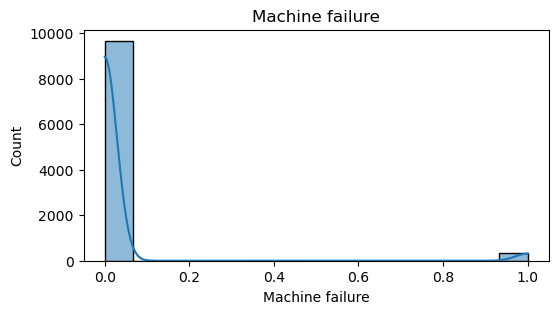

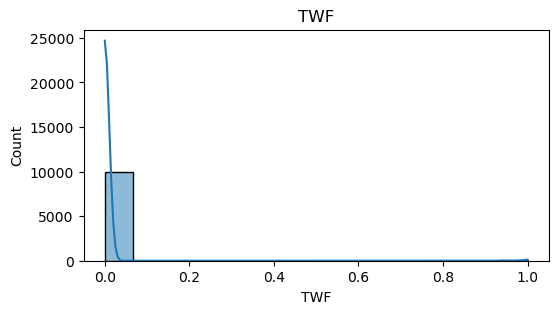

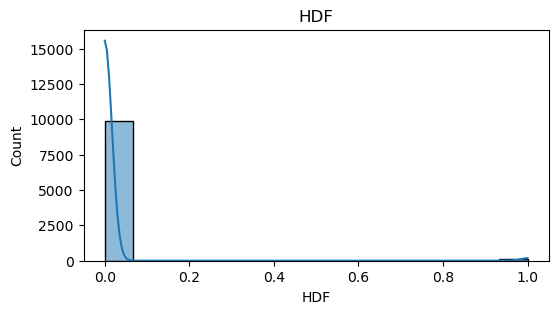

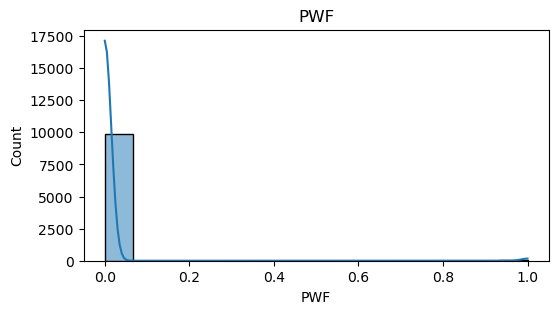

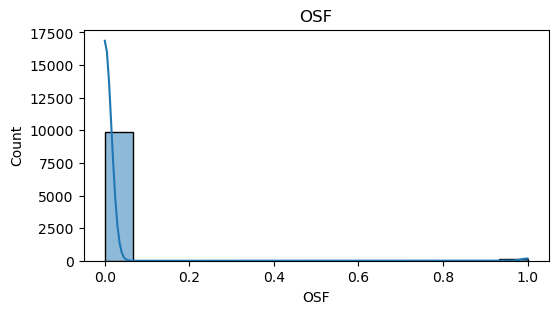

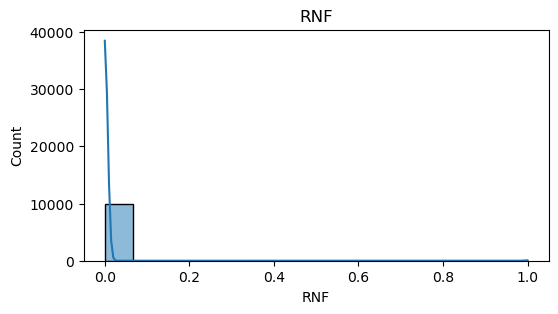

In [9]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(x=df[col], kde=True)
    plt.title(col)
    plt.show()

<Axes: >

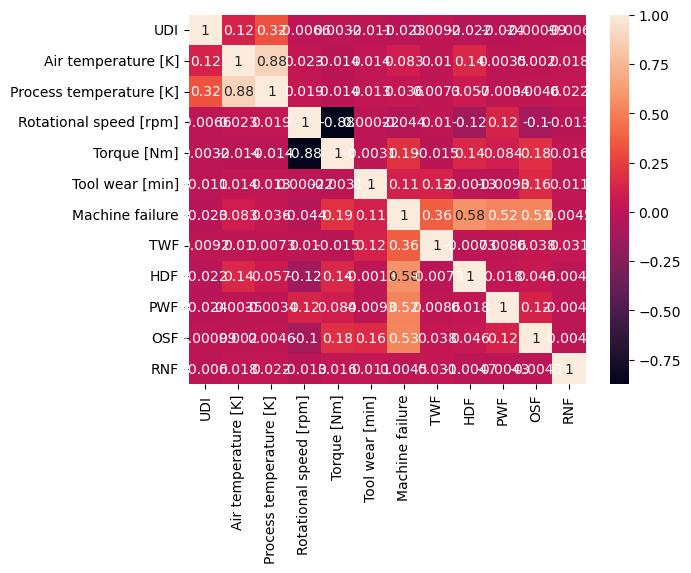

In [10]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

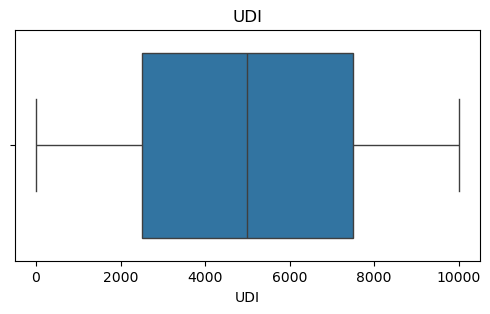

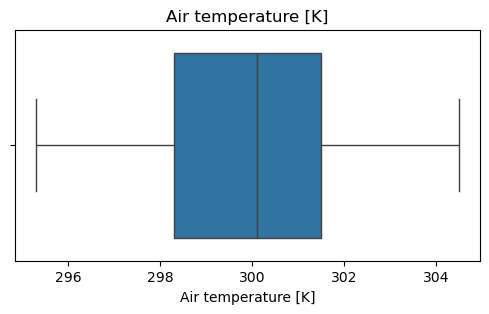

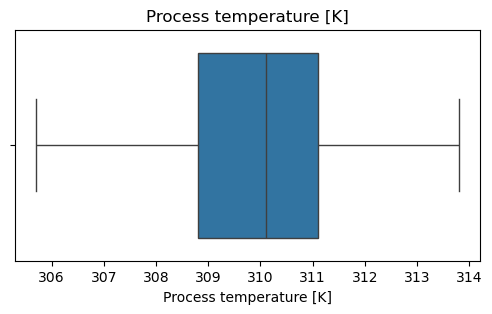

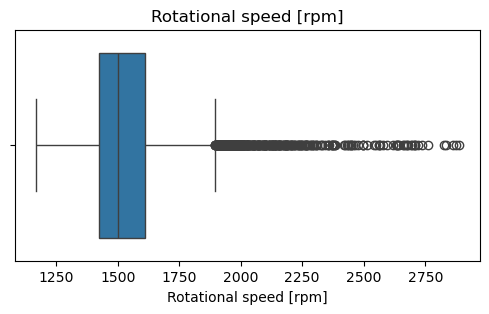

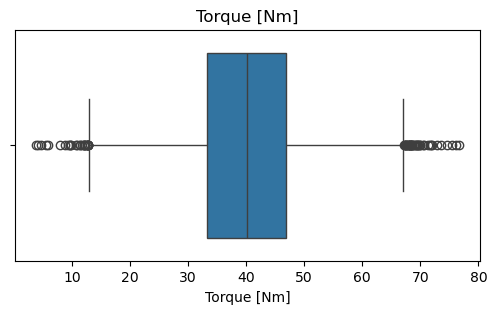

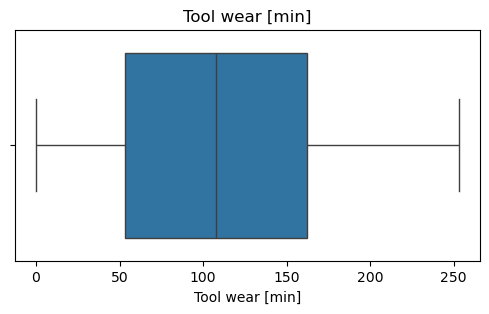

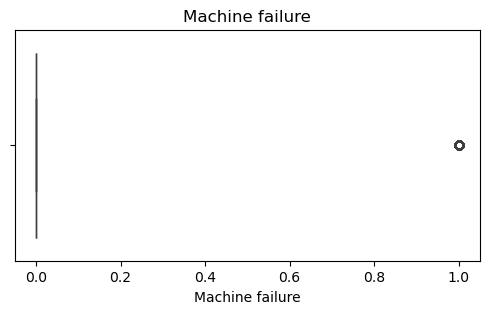

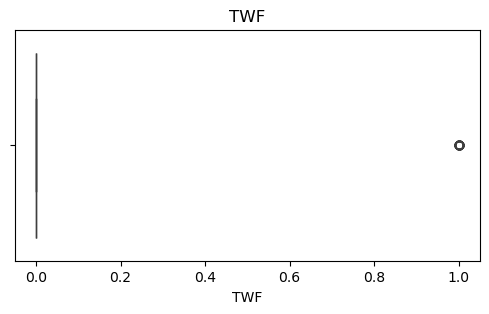

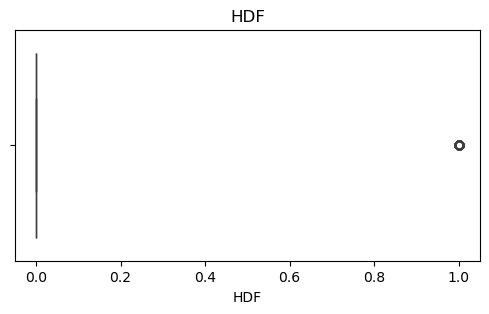

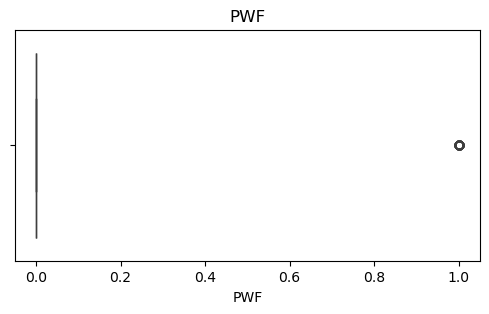

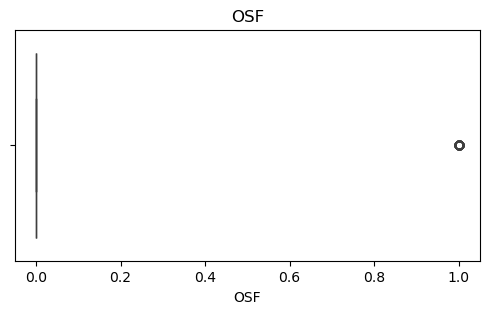

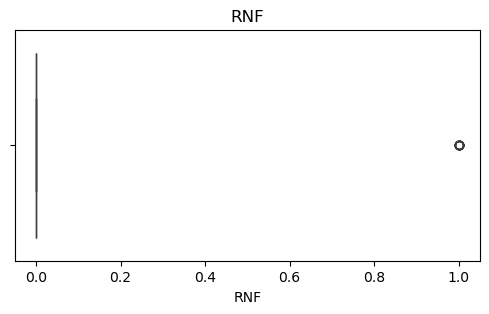

In [11]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

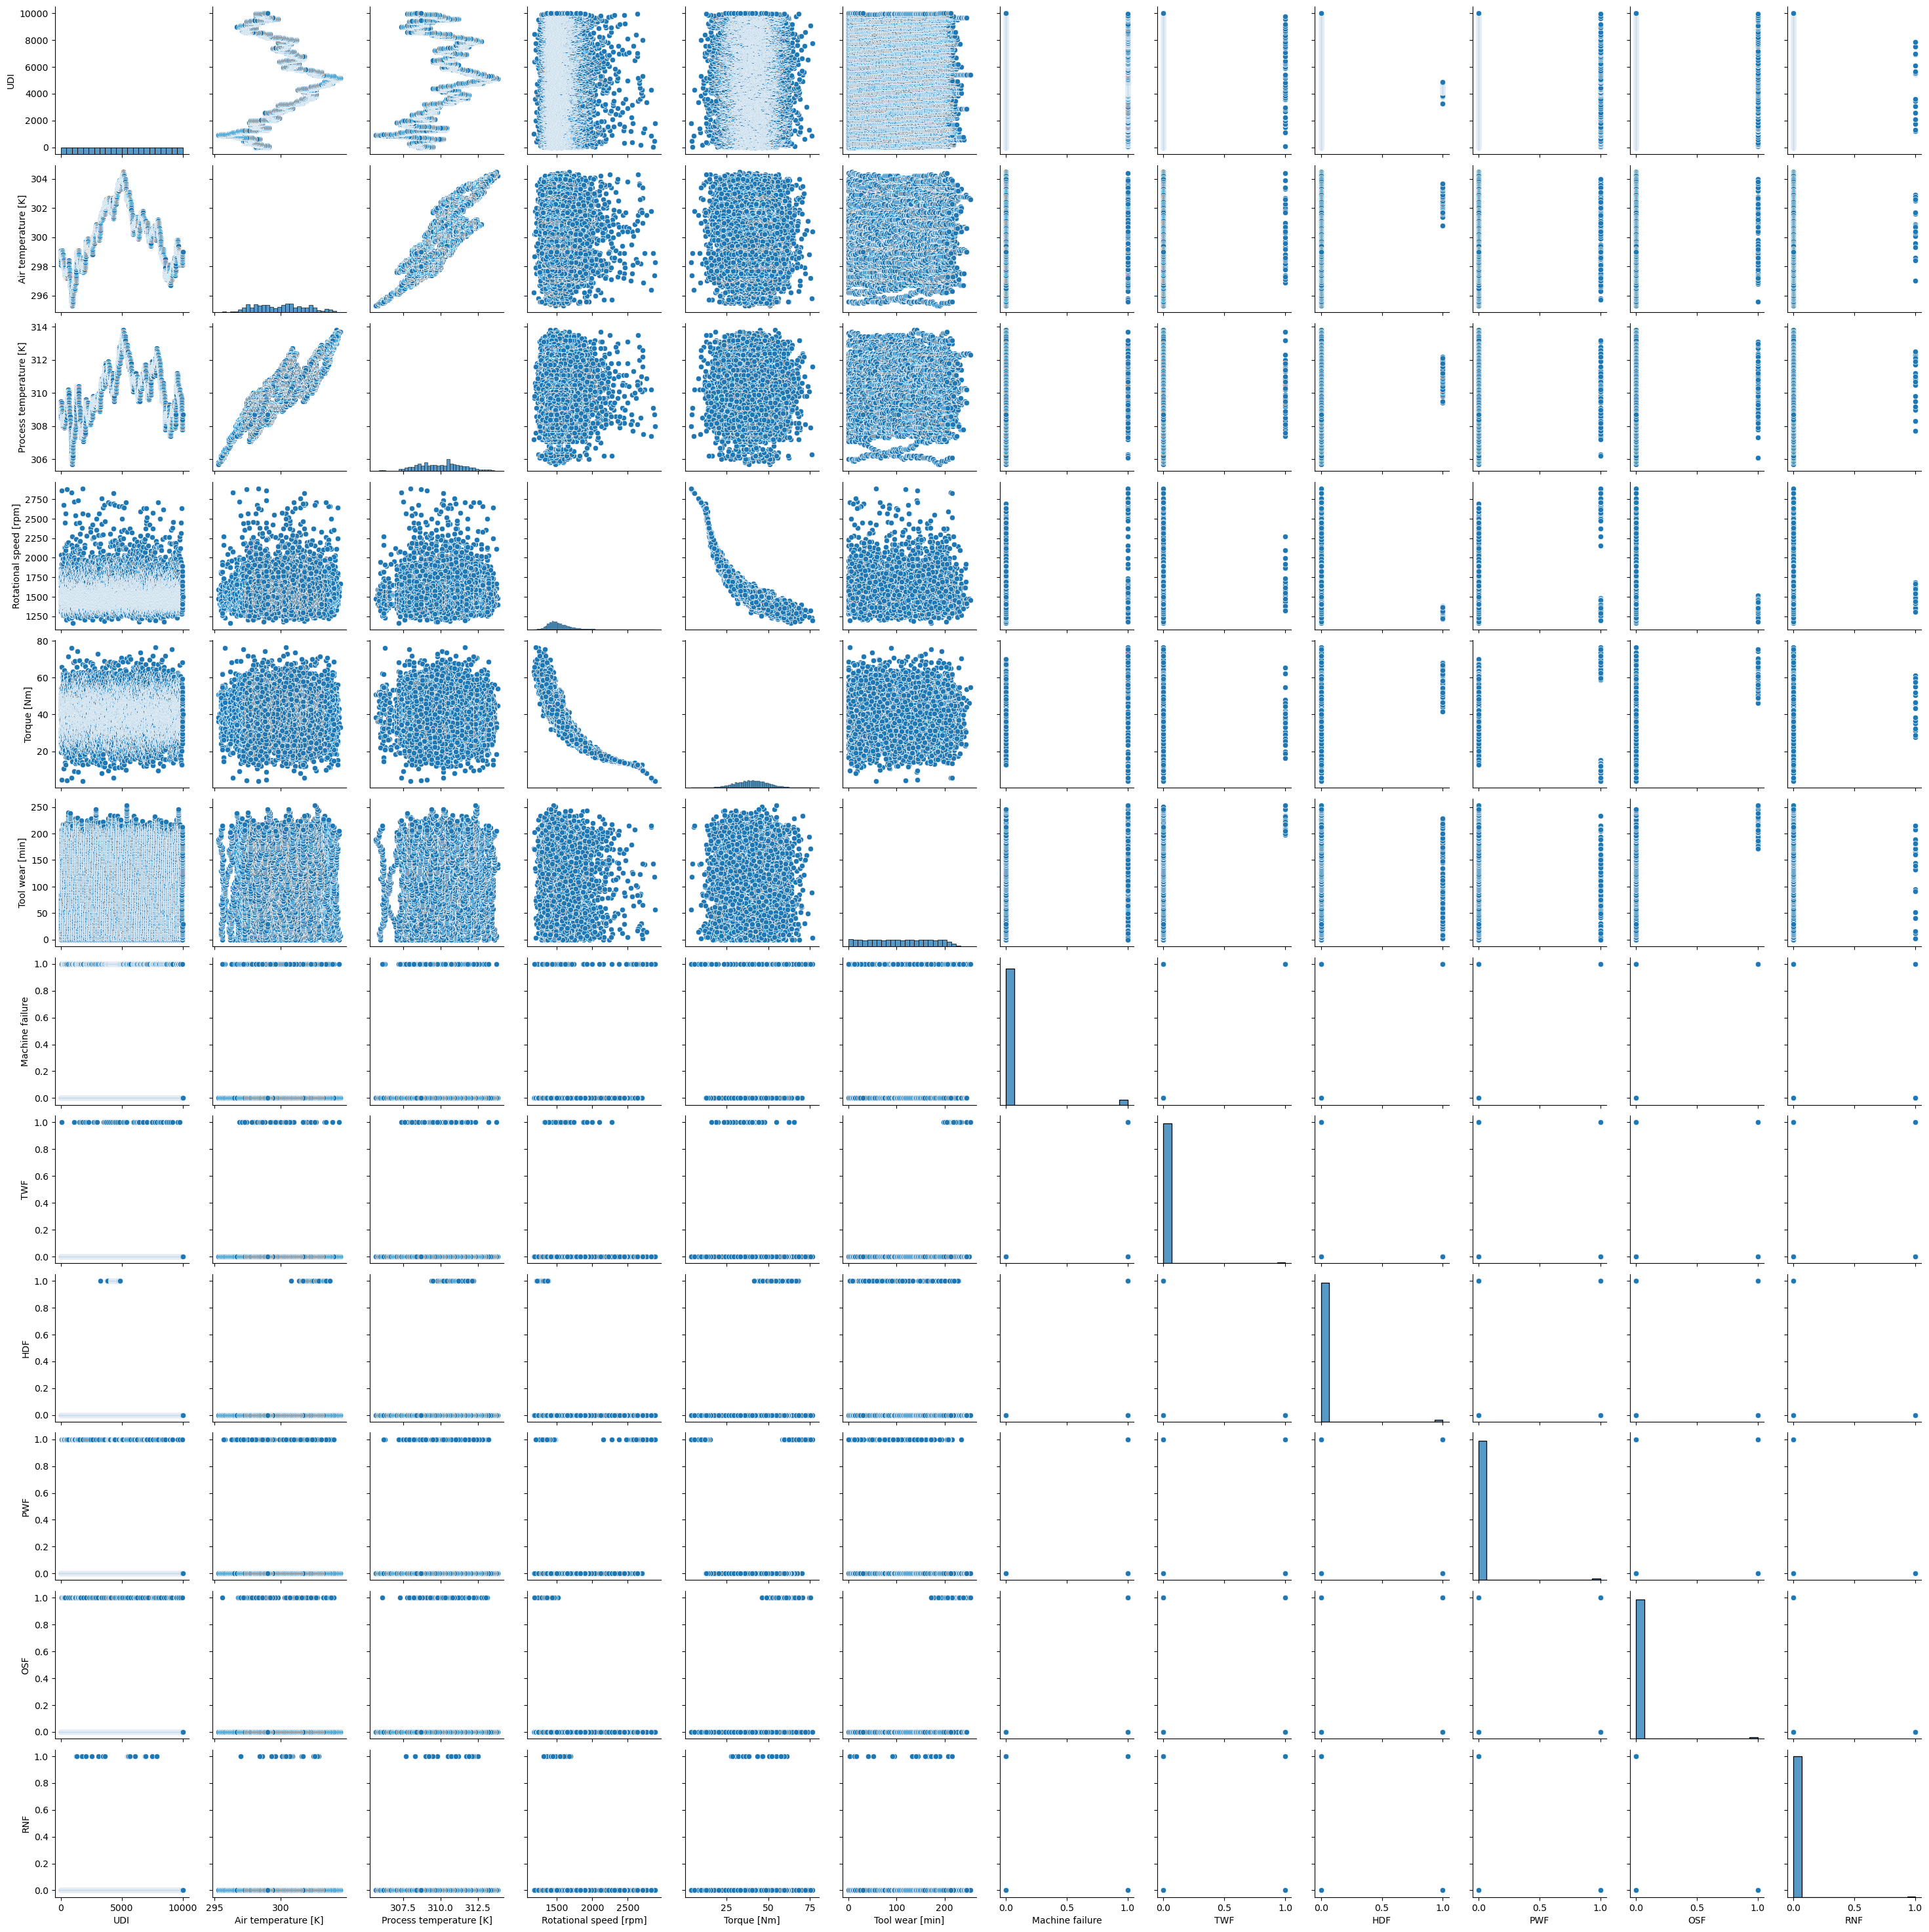

In [12]:
sns.pairplot(df)

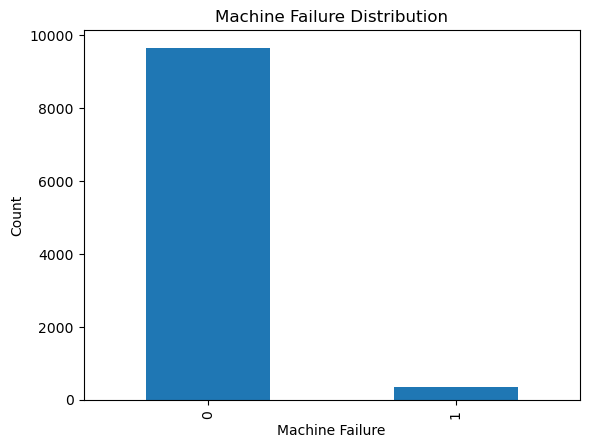

In [13]:
df['Machine failure'].value_counts().plot(kind='bar')

plt.xlabel('Machine Failure')
plt.ylabel('Count')
plt.title('Machine Failure Distribution')
plt.show()

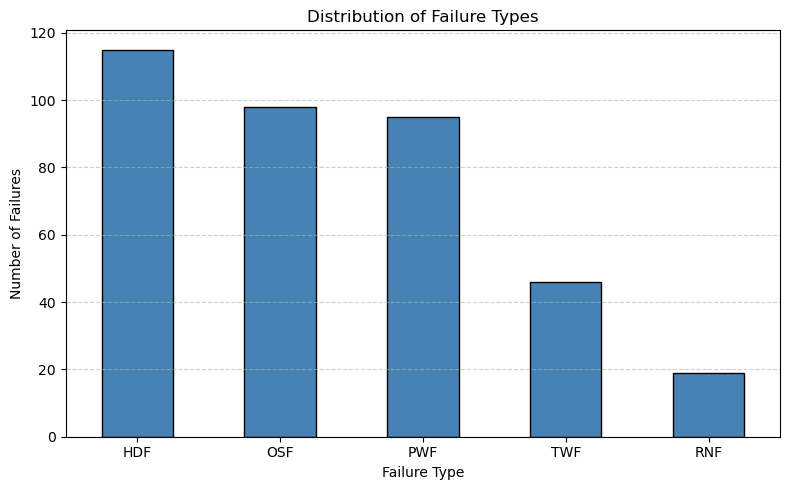

In [14]:
failure_counts = df[['TWF', 'HDF', 'PWF', 'OSF', 'RNF']].sum()

plt.figure(figsize=(8, 5))
failure_counts.sort_values(ascending=False).plot(
    kind='bar',
    color='steelblue',
    edgecolor='black'
)

plt.title('Distribution of Failure Types')
plt.xlabel('Failure Type')
plt.ylabel('Number of Failures')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Feature Engineering

In [15]:
failure_type = pd.Series(0, index=df.index)

failure_type.loc[df["TWF"] == 1] = 1
failure_type.loc[df["HDF"] == 1] = 2
failure_type.loc[df["PWF"] == 1] = 3
failure_type.loc[df["OSF"] == 1] = 4
failure_type.loc[df["RNF"] == 1] = 5

unknown_failure = (
    (df["Machine failure"] == 1) &
    (df["TWF"] == 0) &
    (df["HDF"] == 0) &
    (df["PWF"] == 0) &
    (df["OSF"] == 0) &
    (df["RNF"] == 0)
)

failure_type.loc[unknown_failure] = 5

df["Failure_Type"] = failure_type

In [16]:
df["temperature_difference"] = (
    df["Process temperature [K]"] - df["Air temperature [K]"]
)

df["Power"] = (
    df["Torque [Nm]"] *
    df["Rotational speed [rpm]"] *
    (2 * np.pi / 60.0)
)

df["torque_wear_stress"] = (
    df["Torque [Nm]"] * df["Tool wear [min]"]
)

df["temperature_ratio"] = (
    df["Process temperature [K]"] / df["Air temperature [K]"]
)

df["torque_speed_ratio"] = (
    df["Torque [Nm]"] / df["Rotational speed [rpm]"]
)

df["wear_power_interaction"] = (
    df["Tool wear [min]"] * df["Power"]
)

In [17]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,...,PWF,OSF,RNF,Failure_Type,temperature_difference,Power,torque_wear_stress,temperature_ratio,torque_speed_ratio,wear_power_interaction
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,...,0,0,0,0,10.5,6951.590560,0.0,1.035223,0.027595,0.000000
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,...,0,0,0,0,10.5,6826.722724,138.9,1.035211,0.032884,20480.168172
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,...,0,0,0,0,10.4,7749.387543,247.0,1.034888,0.032977,38746.937713
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,...,0,0,0,0,10.4,5927.504659,276.5,1.034876,0.027565,41492.532612
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,...,0,0,0,0,10.5,5897.816608,360.0,1.035211,0.028409,53080.349475


# Split X and Y

In [18]:
drop_cols = [
    "UDI",
    "Product ID",
    "Machine failure",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF",
    "Failure_Type"
]

X = df.drop(columns=drop_cols)
y = df["Failure_Type"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.2, stratify=y)

In [20]:
print(X_train.shape)
print(y_train.shape)

(8000, 12)
(8000,)


# Data Preprocessing

In [21]:
num_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "temperature_difference",
    "Power",
    "torque_wear_stress",
    "temperature_ratio",
    "torque_speed_ratio",
    "wear_power_interaction"
]

cat_cols = ["Type"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
        ("num", RobustScaler(), num_cols)
    ]
)

# Train Model

In [22]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("oversample", RandomOverSampler(random_state=42)),
    ("classifier", RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ))
])

In [23]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Type']),
                                                 ('num', RobustScaler(),
                                                  ['Air temperature [K]',
                                                   'Process temperature [K]',
                                                   'Rotational speed [rpm]',
                                                   'Torque [Nm]',
                                                   'Tool wear [min]',
                                                   'temperature_difference',
                                                   'Power',
                                                   'torque_wear_stress',
                                                   'temperature_ratio',
                                                   'torque_speed_ratio',
                                                   'wear_power_interaction'])])),
                ('oversample', RandomOverSampler(random_state=42)),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=5, n_estimators=500,
                                        random_state=42))])

In [24]:
rf_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Macro F1:", f1_score(y_test, rf_pred, average="macro"))
print("Weighted F1:", f1_score(y_test, rf_pred, average="weighted"))

print(classification_report(
    y_test,
    rf_pred,
    labels=[0, 1, 2, 3, 4, 5],
    target_names=[
        "No Failure",
        "TWF",
        "HDF",
        "PWF",
        "OSF",
        "Other failure"
    ],
    zero_division=0
))

print(confusion_matrix(y_test, rf_pred, labels=[0, 1, 2, 3, 4, 5]))

Accuracy: 0.9885
Macro F1: 0.6342122048643787
Weighted F1: 0.9856109542631283
               precision    recall  f1-score   support

   No Failure       0.99      1.00      0.99      1928
          TWF       0.00      0.00      0.00         8
          HDF       0.83      0.95      0.89        21
          PWF       1.00      0.94      0.97        17
          OSF       0.91      1.00      0.95        20
Other failure       0.00      0.00      0.00         6

     accuracy                           0.99      2000
    macro avg       0.62      0.65      0.63      2000
 weighted avg       0.98      0.99      0.99      2000

[[1921    2    4    0    1    0]
 [   8    0    0    0    0    0]
 [   0    0   20    0    1    0]
 [   1    0    0   16    0    0]
 [   0    0    0    0   20    0]
 [   6    0    0    0    0    0]]


In [25]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("oversample", SMOTE(random_state=42)),
    ("classifier", XGBClassifier(
        max_depth=8, learning_rate=0.01, n_estimators=200,
        objective='multi:softprob', eval_metric='mlogloss', random_state=42
    ))
])

In [26]:
xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Type']),
                                                 ('num', RobustScaler(),
                                                  ['Air temperature [K]',
                                                   'Process temperature [K]',
                                                   'Rotational speed [rpm]',
                                                   'Torque [Nm]',
                                                   'Tool wear [min]',
                                                   'temperature_difference',
                                                   'Power',
                                                   'torque_wear_stress',
                                                   'temperature_ratio',
                                                   'torque_speed_ratio',
                                                   'we...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=8, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [27]:
xgb_pred = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Macro F1:", f1_score(y_test, xgb_pred, average="macro"))
print("Weighted F1:", f1_score(y_test, xgb_pred, average="weighted"))

print(classification_report(
    y_test,
    xgb_pred,
    labels=[0, 1, 2, 3, 4, 5],
    target_names=[
        "No Failure",
        "TWF",
        "HDF",
        "PWF",
        "OSF",
        "Other failure"
    ],
    zero_division=0
))

print(confusion_matrix(y_test, xgb_pred, labels=[0, 1, 2, 3, 4, 5]))

Accuracy: 0.8905
Macro F1: 0.6125176901747402
Weighted F1: 0.9326828809963239
               precision    recall  f1-score   support

   No Failure       0.99      0.89      0.94      1928
          TWF       0.06      0.50      0.11         8
          HDF       0.86      0.90      0.88        21
          PWF       0.81      0.76      0.79        17
          OSF       0.90      0.95      0.93        20
Other failure       0.01      0.33      0.03         6

     accuracy                           0.89      2000
    macro avg       0.61      0.72      0.61      2000
 weighted avg       0.98      0.89      0.93      2000

[[1724   62    3    3    1  135]
 [   4    4    0    0    0    0]
 [   2    0   19    0    0    0]
 [   2    0    0   13    1    1]
 [   1    0    0    0   19    0]
 [   4    0    0    0    0    2]]


In [29]:
rf_macro_f1 = f1_score(y_test, rf_pred, average="macro")
xgb_macro_f1 = f1_score(y_test, xgb_pred, average="macro")

if xgb_macro_f1 > rf_macro_f1:
    best_model = xgb_model
    best_model_name = "Extra Trees"
else:
    best_model = xgb_model
    best_model_name = "Random Forest"

print("Best model:", best_model_name)

Best model: Random Forest


Although Random Forest achieved a slightly higher Macro F1 Score and overall accuracy, it completely failed to identify the TWF and Other Failure classes. Since the primary objective of predictive maintenance is to detect potential failures before they occur, XGBoost was selected as the deployment model because it successfully identified these rare but operationally critical failure types. This decision prioritizes business impact over a modest improvement in aggregate classification metrics.

In [30]:
best_model = xgb_model

# Save Model

In [31]:
joblib.dump(best_model, "predictive_maintenance_model.pkl")

['predictive_maintenance_model.pkl']

# Prediction

In [32]:
failure_map = {
    0: "No Failure",
    1: "TWF",
    2: "HDF",
    3: "PWF",
    4: "OSF",
    5: "Other failure"
}

In [33]:
def prepare_input(
    machine_type,
    air_temperature_k,
    process_temperature_k,
    rotational_speed_rpm,
    torque_nm,
    tool_wear_min
):
    temperature_difference = process_temperature_k - air_temperature_k
    power = torque_nm * rotational_speed_rpm * (2 * np.pi / 60.0)
    torque_wear_stress = torque_nm * tool_wear_min
    temperature_ratio = process_temperature_k / air_temperature_k
    torque_speed_ratio = torque_nm / rotational_speed_rpm
    wear_power_interaction = tool_wear_min * power

    return pd.DataFrame({
        "Type": [machine_type],
        "Air temperature [K]": [air_temperature_k],
        "Process temperature [K]": [process_temperature_k],
        "Rotational speed [rpm]": [rotational_speed_rpm],
        "Torque [Nm]": [torque_nm],
        "Tool wear [min]": [tool_wear_min],
        "temperature_difference": [temperature_difference],
        "Power": [power],
        "torque_wear_stress": [torque_wear_stress],
        "temperature_ratio": [temperature_ratio],
        "torque_speed_ratio": [torque_speed_ratio],
        "wear_power_interaction": [wear_power_interaction]
    })

In [34]:
def predict_failure(input_data, model=best_model):
    pred = model.predict(input_data)[0]
    prob = model.predict_proba(input_data)[0]

    probabilities = {
        failure_map[i]: round(float(prob[i]), 4)
        for i in range(6)
    }

    return {
        "failure": bool(pred != 0),
        "failure_type": failure_map[pred],
        "predicted_class": int(pred),
        "confidence": round(float(prob[pred]), 4),
        "probabilities": probabilities
    }

In [35]:
new_input = prepare_input(
    machine_type="L",
    air_temperature_k=298.0,
    process_temperature_k=308.2,
    rotational_speed_rpm=1348,
    torque_nm=58.8,
    tool_wear_min=202
)

result = predict_failure(new_input)
result

{'failure': True,
 'failure_type': 'OSF',
 'predicted_class': 4,
 'confidence': 0.8344,
 'probabilities': {'No Failure': 0.0332,
  'TWF': 0.0332,
  'HDF': 0.033,
  'PWF': 0.033,
  'OSF': 0.8344,
  'Other failure': 0.0331}}